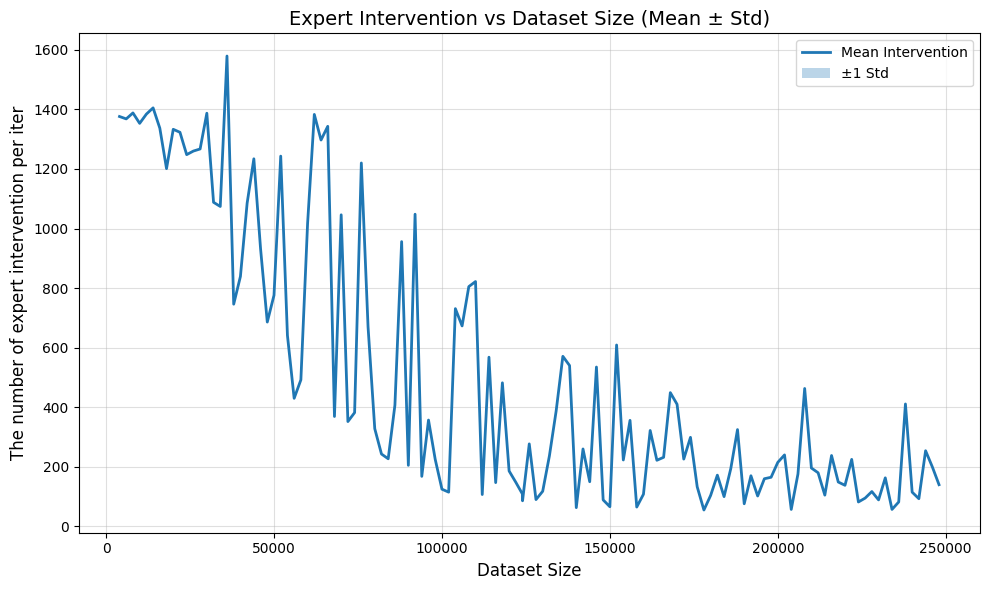

In [3]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_nswitch_from_checkpoints(checkpoint_roots):
    """
    checkpoint_roots: list of str
        [
          "/AILAB-summer-school-2025/.../exp1",
          "/AILAB-summer-school-2025/.../exp2",
          "/AILAB-summer-school-2025/.../exp3",
        ]
    """

    all_nswitches = []
    dataset_sizes_ref = None

    for root in checkpoint_roots:
        result_path = os.path.join(root, "results.json")

        if not os.path.exists(result_path):
            raise FileNotFoundError(f"results.json not found: {result_path}")

        with open(result_path, "r") as f:
            results = json.load(f)

        dataset_sizes = np.array(results["dataset_sizes"])
        nswitches = np.array(results["nswitches"])

        # 첫 번째 checkpoint를 기준으로 dataset size 고정
        if dataset_sizes_ref is None:
            dataset_sizes_ref = dataset_sizes
        else:
            if not np.allclose(dataset_sizes_ref, dataset_sizes):
                raise ValueError(f"Dataset size mismatch in {root}")

        all_nswitches.append(nswitches)

    all_nswitches = np.stack(all_nswitches, axis=0)   # (N_checkpoints, T)

    mean_nswitch = np.mean(all_nswitches, axis=0)
    std_nswitch  = np.std(all_nswitches, axis=0)

    # -------------------------------
    # Plot
    # -------------------------------
    plt.figure(figsize=(10, 6))

    # mean line
    plt.plot(dataset_sizes_ref, mean_nswitch,
             linewidth=2,
             label="Mean Intervention")

    # std shading
    plt.fill_between(
        dataset_sizes_ref,
        mean_nswitch - std_nswitch,
        mean_nswitch + std_nswitch,
        alpha=0.3,
        label="±1 Std"
    )

    plt.xlabel("Dataset Size", fontsize=12)
    plt.ylabel("The number of expert intervention per iter", fontsize=12)
    plt.title("Expert Intervention vs Dataset Size (Mean ± Std)", fontsize=14)

    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

checkpoint_dirs = [
    "/AILAB-summer-school-2025/RND/checkpoints/[Balanced_Dagger]rnd_iter200_balance_True_epoch_10_alpha_0.7_minDemo70_H0_FTrue"
]

plot_nswitch_from_checkpoints(checkpoint_dirs)
